In [1]:
from aicsimageio import AICSImage
from skimage.io import imshow
from matplotlib import pyplot as plt
import numpy as np
from skimage import transform, draw
import xml.etree.ElementTree as ET
from matplotlib.colors import LinearSegmentedColormap
import sklearn
import operator
import scipy

In [2]:
lst = open("C:/Users/c23115040/OneDrive - Cardiff University/Desktop/Pathologist Intercorrelation Analysis/Sequential_H&E/list.txt", "r")
lst = lst.read()
lst = lst.split("\n")

In [3]:
lst2 = open("C:/Users/c23115040/OneDrive - Cardiff University/Desktop/Pathologist Intercorrelation Analysis/Pathologist_A/list.txt", "r")
lst2 = lst2.read()
lst2 = lst2.split("\n")

In [4]:
lst3 = open("C:/Users/c23115040/OneDrive - Cardiff University/Desktop/Pathologist Intercorrelation Analysis/Pathologist_B/list.txt", "r")
lst3 = lst3.read()
lst3 = lst3.split("\n")

In [5]:
lst_cmp = open("C:/Users/c23115040/OneDrive - Cardiff University/Desktop/Pathologist Intercorrelation Analysis/list1.txt", "r")
lst_cmp = lst_cmp.read()
lst_cmp = lst_cmp.split("\n")

list_ann_cmp = open("C:/Users/c23115040/OneDrive - Cardiff University/Desktop/Pathologist Intercorrelation Analysis/list2.txt", "r")
list_ann_cmp = list_ann_cmp.read()
list_ann_cmp = list_ann_cmp.split("\n")

list_char_cmp = []
list_char_ann_cmp = []

for i in range(len(lst_cmp)):
    list_char_cmp.append(lst_cmp[i][7:10])

for i in range(len(list_ann_cmp)):
    list_char_ann_cmp.append(list_ann_cmp[i][7:10])
    
labels_cmp = [i for i, item in enumerate(list_char_cmp) if item in set(list_char_ann_cmp)]

lst_cmp = operator.itemgetter(*labels_cmp)(lst_cmp)

lst_cmp2 = []
for i in range(len(lst_cmp)):
    lst_cmp2.append(lst_cmp[i][7:10])

In [6]:
def extract_annotations_from_metadata(metadata, scale):
    root = metadata[0]
    masks_healthy = []  
    masks_gleason3 = []
    masks_gleason4 = []
    masks_cribriform = []
    masks_glomeruloid = []
    masks_gleason5 = []
    #annotations = {} 
    img_width = round(float(root.find('./Information/Image/SizeX').text)*scale)
    img_height = round(float(root.find('./Information/Image/SizeY').text)*scale)

     #Contour_polygon
    for polygon in root.iter('Polygon'):
        try:
            color = polygon.find('./Attributes/Stroke').text
        except:
            continue
        points = polygon.find('./Geometry/Points').text
        array = np.array(np.mat(points.replace(' ', ';'))*scale, dtype=np.int64)
        r = array[:,1]
        c = array[:,0]
        img_polygon = np.zeros((img_height, img_width), dtype=np.int64)
        try:
            rotation = -float(polygon.find('./Attributes/Rotation').text)
            rr, cc = draw.polygon(r, c)
            img_polygon[rr, cc] = 1
            centerX = round(np.min(cc) + 0.5*(np.max(cc)-np.min(cc)))
            centerY = round(np.min(rr) + 0.5*(np.max(rr)-np.min(rr)))
            img_polygon = transform.rotate(img_polygon, angle=rotation, center=(centerX,centerY), order=0)
            rr, cc = np.where(img_polygon==1)
        except:   
            rr, cc  = draw.polygon(r, c)
            img_polygon[rr, cc ] = 1

        #annotations[label] = (rr, cc )
        match color:
            case "#FF0000FF":
                masks_healthy.append(img_polygon)
            case "#FF00FF00":
                masks_gleason3.append(img_polygon)
            case "#FFFF6600":
                masks_gleason4.append(img_polygon)
            case "#FFCC4E00":
                masks_cribriform.append(img_polygon)  
            case "#FFFF00FF":
                masks_glomeruloid.append(img_polygon)
            case "#FF990000":
                masks_gleason5.append(img_polygon)
    
    #Contour_spline
    for bezier in root.iter('Bezier'):
        try:
            color = bezier.find('./Attributes/Stroke').text
        except:
            continue
        points = bezier.find('./Geometry/Points').text
        array = np.array(np.mat(points.replace(' ', ';'))*scale, dtype=np.int64)
        r = array[:,1]
        c = array[:,0]
        img_bezier = np.zeros((img_height, img_width), dtype=np.int64)
        try:
            rotation = -float(bezier.find('./Attributes/Rotation').text)
            rr, cc = draw.polygon(r, c)
            img_bezier[rr, cc] = 1
            centerX = round(np.min(cc) + 0.5*(np.max(cc)-np.min(cc)))
            centerY = round(np.min(rr) + 0.5*(np.max(rr)-np.min(rr)))
            img_bezier = transform.rotate(img_bezier, angle=rotation, center=(centerX,centerY), order=0)
            rr, cc = np.where(img_bezier==1)
        except:   
            rr, cc  = draw.polygon(r, c)
            img_bezier[rr, cc ] = 1

        #annotations[label] = (rr, cc )
        match color:
            case "#FF0000FF":
                masks_healthy.append(img_bezier)
            case "#FF00FF00":
                masks_gleason3.append(img_bezier)
            case "#FFFF6600":
                masks_gleason4.append(img_bezier)
            case "#FFCC4E00":
                masks_cribriform.append(img_bezier)
            case "#FFFF00FF":
                masks_glomeruloid.append(img_bezier)
            case "#FF990000":
                masks_gleason5.append(img_bezier)

    #Contour with holes
    for bezier in root.iter('MultiPolygon'):
        try:
            color = bezier.find('./Attributes/Stroke').text
        except:
            continue
        points_big = bezier.find('./Geometry/Points').text
        points_small = bezier.findall('ChildPolygon')
        array_big = np.array(np.mat(points_big.replace(' ', ';'))*scale, dtype=np.int64)
        r_big = array_big[:,1]
        c_big = array_big[:,0]
        img_big = np.zeros((img_height, img_width), dtype=np.int64)
        rr_big, cc_big  = draw.polygon(r_big, c_big)
        img_big[rr_big, cc_big ] = 1
        img_small = np.zeros((img_height, img_width), dtype=np.int64)
        for i in range(len(points_small)):
            points = points_small[i].find('Geometry/Points').text
            array_small = np.array(np.mat(points.replace(' ', ';'))*scale, dtype=np.int64)
            r_small = array_small[:,1]
            c_small = array_small[:,0]
            rr_small, cc_small  = draw.polygon(r_small, c_small)
            img_small[rr_small, cc_small ] = 1
        img_big[img_small == 1] = 0 

        #annotations[label] = (rr, cc )
        match color:
            case "#FF0000FF":
                masks_healthy.append(img_big)
            case "#FF00FF00":
                masks_gleason3.append(img_big)
            case "#FFFF6600":
                masks_gleason4.append(img_big)
            case "#FFCC4E00":
                masks_cribriform.append(img_big) 
            case "#FFFF00FF":
                masks_glomeruloid.append(img_big)
            case "#FF990000":
                masks_gleason5.append(img_big)

    # circle
    for circle in root.iter('Circle'):
        try:
            color = circle.find('./Attributes/Stroke').text
        except:
            continue
        centerX = round(float(circle.find('./Geometry/CenterX').text)*scale)
        centerY = round(float(circle.find('./Geometry/CenterY').text)*scale)
        radius = round(float(circle.find('./Geometry/Radius').text)*scale)
        img_circle = np.zeros((img_height, img_width), dtype=np.int64)
        rr, cc = draw.disk((centerY, centerX ), radius)
        img_circle[rr, cc ] = 1

        #annotations[label] = (rr, cc )
        match color:
            case "#FF0000FF":
                masks_healthy.append(img_circle)
            case "#FF00FF00":
                masks_gleason3.append(img_circle)
            case "#FFFF6600":
                masks_gleason4.append(img_circle)
            case "#FFCC4E00":
                masks_cribriform.append(img_circle)
            case "#FFFF00FF":
                masks_glomeruloid.append(img_circle)
            case "#FF990000":
                masks_gleason5.append(img_circle)
    
    # ellipse
    for ellipse in root.iter('Ellipse'): 
        try:
            color = ellipse.find('./Attributes/Stroke').text
        except:
            continue
        centerX = round(float(ellipse.find('./Geometry/CenterX').text)*scale)
        centerY = round(float(ellipse.find('./Geometry/CenterY').text)*scale)
        radiusX = round(float(ellipse.find('./Geometry/RadiusX').text)*scale)
        radiusY = round(float(ellipse.find('./Geometry/RadiusY').text)*scale)
        img_ellipse = np.zeros((img_height, img_width),dtype=np.int64)
        try:
            rotation = -float(ellipse.find('./Attributes/Rotation').text)
            rr, cc = draw.ellipse(centerY, centerX , radiusY, radiusX)
            img_ellipse[rr, cc] = 1
            img_ellipse = transform.rotate(img_ellipse, angle=rotation, center=(centerX,centerY), order=0)
            rr, cc = np.where(img_ellipse==1)
        except:
            rr, cc = draw.ellipse(centerY, centerX , radiusY, radiusX)
            img_ellipse[rr, cc] = 1

        #annotations[label] = (rr, cc )
        match color:
            case "#FF0000FF":
                masks_healthy.append(img_ellipse)
            case "#FF00FF00":
                masks_gleason3.append(img_ellipse)
            case "#FFFF6600":
                masks_gleason4.append(img_ellipse)
            case "#FFCC4E00":
                masks_cribriform.append(img_ellipse) 
            case "#FFFF00FF":
                masks_glomeruloid.append(img_ellipse)
            case "#FF990000":
                masks_gleason5.append(img_ellipse)

    # rectangle
    for rectangle in root.iter('Rectangle'):
        try:
            color = rectangle.find('./Attributes/Stroke').text
        except:
            continue
        left = round(float(rectangle.find('./Geometry/Left').text)*scale)
        top = round(float(rectangle.find('./Geometry/Top').text)*scale)
        width = round(float(rectangle.find('./Geometry/Width').text)*scale)
        height = round(float(rectangle.find('./Geometry/Height').text)*scale)
        img_rectangle = np.zeros((img_height, img_width),dtype=np.int64)
        try:
            rotation = -float(rectangle.find('./Attributes/Rotation').text)
            rr, cc = draw.rectangle((top,left), end=(top+height, left+width))
            img_rectangle[rr, cc] = 1
            centerX = round(left+0.5*width)
            centerY = round(top+0.5*height)
            img_rectangle = transform.rotate(img_rectangle, angle=rotation, center=(centerX,centerY), order=0)
            rr, cc = np.where(img_rectangle==1)
        except:
            rr, cc = draw.rectangle((top,left), end=(top+height, left+width)) 
            img_rectangle[rr, cc] = 1

        #annotations[label] = (rr, cc )
        match color:
            case "#FF0000FF":
                masks_healthy.append(img_rectangle)
            case "#FF00FF00":
                masks_gleason3.append(img_rectangle)
            case "#FFFF6600":
                masks_gleason4.append(img_rectangle)
            case "#FFCC4E00":
                masks_cribriform.append(img_rectangle) 
            case "#FFFF00FF":
                masks_glomeruloid.append(img_rectangle)
            case "#FF990000":
                masks_gleason5.append(img_rectangle)

    masks = [masks_healthy, masks_gleason3, masks_gleason4, masks_cribriform, masks_glomeruloid, masks_gleason5]
    return masks

In [7]:
epithelials3 = np.load("C:/Users/c23115040/OneDrive - Cardiff University/Desktop/Pathologist Intercorrelation Analysis/epithelials3.npy", allow_pickle=True)
epithelials3 = operator.itemgetter(*labels_cmp)(epithelials3)

In [8]:
common = []
for i in range(len(lst)):
    common.append(lst_cmp2.index(lst[i][7:10]))

In [9]:
transfered_masks = []

for i in range(len(lst)):
    img = AICSImage("C:/Users/c23115040/OneDrive - Cardiff University/Desktop/Pathologist Intercorrelation Analysis/Sequential_H&E/" + lst[i] + ".czi")
    #breakpoint()
    scale = 1
    img_width =round(img.shape[4]*scale)
    img_height = round(img.shape[3]*scale)
    img_data = np.zeros((img_height, img_width, 3))
    for c in range(3):
        img_data[:,:, c] = transform.rescale(img.get_image_data("YX", S=c), scale, anti_aliasing=False)
    masks = extract_annotations_from_metadata(img.metadata, scale)  
    annotations = []
    for j in range(6):
        match len(masks[j]):
            case 0:
                annotations.append(np.zeros((img_height, img_width)).astype(bool))
            case 1:
                annotations.append(np.array(masks[j]).astype(bool)[0,:,:])
            case _ if len(masks[j]) >= 2:
                annotations.append(np.logical_or.reduce(np.array(masks[j])))
    final_mask = np.zeros((img_height, img_width, 1))
    final_mask[annotations[0] == 1] = 1
    final_mask[annotations[1] == 1] = 2
    final_mask[annotations[2] == 1] = 3
    final_mask[annotations[3] == 1] = 4
    final_mask[annotations[4] == 1] = 5 
    final_mask[annotations[5] == 1] = 6
    transfered_masks.append(final_mask)

In [10]:
patholog_A_masks = []

for i in range(len(lst2)):
    img = AICSImage("C:/Users/c23115040/OneDrive - Cardiff University/Desktop/Pathologist Intercorrelation Analysis/Pathologist_A/" + lst2[i] + ".czi")
    #breakpoint()
    scale = 1
    img_width =round(img.shape[4]*scale)
    img_height = round(img.shape[3]*scale)
    img_data = np.zeros((img_height, img_width, 3))
    for c in range(3):
        img_data[:,:, c] = transform.rescale(img.get_image_data("YX", S=c), scale, anti_aliasing=False)
    masks = extract_annotations_from_metadata(img.metadata, scale)  
    annotations = []
    for j in range(6):
        match len(masks[j]):
            case 0:
                annotations.append(np.zeros((img_height, img_width)).astype(bool))
            case 1:
                annotations.append(np.array(masks[j]).astype(bool)[0,:,:])
            case _ if len(masks[j]) >= 2:
                annotations.append(np.logical_or.reduce(np.array(masks[j])))
    final_mask = np.zeros((img_height, img_width, 1))
    final_mask[annotations[0] == 1] = 1
    final_mask[annotations[1] == 1] = 2
    final_mask[annotations[2] == 1] = 3
    final_mask[annotations[3] == 1] = 4
    final_mask[annotations[4] == 1] = 5 
    final_mask[annotations[5] == 1] = 6
    patholog_A_masks.append(final_mask)

In [11]:
patholog_B_masks = []

for i in range(len(lst3)):
    img = AICSImage("C:/Users/c23115040/OneDrive - Cardiff University/Desktop/Pathologist Intercorrelation Analysis/Pathologist_B/" + lst3[i] + ".czi")
    #breakpoint()
    scale = 1
    img_width =round(img.shape[4]*scale)
    img_height = round(img.shape[3]*scale)
    img_data = np.zeros((img_height, img_width, 3))
    for c in range(3):
        img_data[:,:, c] = transform.rescale(img.get_image_data("YX", S=c), scale, anti_aliasing=False)
    masks = extract_annotations_from_metadata(img.metadata, scale)  
    annotations = []
    for j in range(6):
        match len(masks[j]):
            case 0:
                annotations.append(np.zeros((img_height, img_width)).astype(bool))
            case 1:
                annotations.append(np.array(masks[j]).astype(bool)[0,:,:])
            case _ if len(masks[j]) >= 2:
                annotations.append(np.logical_or.reduce(np.array(masks[j])))
    final_mask = np.zeros((img_height, img_width, 1))
    final_mask[annotations[0] == 1] = 1
    final_mask[annotations[1] == 1] = 2
    final_mask[annotations[2] == 1] = 3
    final_mask[annotations[3] == 1] = 4
    final_mask[annotations[4] == 1] = 5 
    final_mask[annotations[5] == 1] = 6
    patholog_B_masks.append(final_mask)

In [12]:
for i in range(len(lst)):
    transfered_masks[i][epithelials3[common[i]] == 0] = 0
    transfered_masks[i][transfered_masks[i] > 2] = 3
    patholog_A_masks[i][epithelials3[common[i]] == 0] = 0
    patholog_A_masks[i][patholog_A_masks[i] > 2] = 3
    patholog_B_masks[i][epithelials3[common[i]] == 0] = 0
    patholog_B_masks[i][patholog_B_masks[i] > 2] = 3

In [13]:
scores_tsf_vs_A = []
scores_tsf_vs_B = []
scores_A_vs_B = []
for i in range(10):
    scores_tsf_vs_A.append(1 - scipy.spatial.distance.dice((transfered_masks[i] > 0).ravel(), (patholog_A_masks[i] > 0).ravel()))
    scores_tsf_vs_B.append(1 - scipy.spatial.distance.dice((transfered_masks[i] > 0).ravel(), (patholog_B_masks[i] > 0).ravel()))
    scores_A_vs_B.append(1 - scipy.spatial.distance.dice((patholog_A_masks[i] > 0).ravel(), (patholog_B_masks[i] > 0).ravel()))

In [14]:
scores_tsf_vs_A

[0.7546776883796446,
 0.9607054212346219,
 0.8509054903223098,
 0.8601284539665306,
 0.9654151588730665,
 0.8681618773588431,
 0.8921255972729216,
 0.9199807505459596,
 0.9250649544965639,
 0.8838217008655357]

In [15]:
scores_tsf_vs_B

[0.8104995853501217,
 0.9807200791238453,
 0.8837314425140681,
 0.7789493781839326,
 0.9676003217302294,
 0.9369690065973706,
 0.8155759366552736,
 0.9376499088554159,
 0.9122996811659346,
 0.9211861558793392]

In [16]:
scores_A_vs_B

[0.7838109425670962,
 0.9601281444602181,
 0.8975042553814009,
 0.7807051284445125,
 0.9569205096859323,
 0.8655094813817172,
 0.816378581854498,
 0.9237143048430959,
 0.9161794003462382,
 0.8327393517734806]

In [58]:
scores_tsf_vs_A = []
scores_tsf_vs_B = []
scores_A_vs_B = []
for i in range(10):
    scores_tsf_vs_A.append(sklearn.metrics.cohen_kappa_score((transfered_masks[i]).ravel(), (patholog_A_masks[i]).ravel(), weights = 'quadratic'))
    scores_tsf_vs_B.append(sklearn.metrics.cohen_kappa_score((transfered_masks[i]).ravel(), (patholog_B_masks[i]).ravel(), weights = 'quadratic'))
    scores_A_vs_B.append(sklearn.metrics.cohen_kappa_score((patholog_A_masks[i]).ravel(), (patholog_B_masks[i]).ravel(), weights = 'quadratic'))

In [70]:
scores_tsf_vs_A

[0.6899713354438133,
 0.963572158839529,
 0.5856944780906254,
 0.8506527042905299,
 0.8968775557159409,
 0.856873120065637,
 0.8804151427205231,
 0.9131977084607092,
 0.8559478373002809,
 0.8188254155805048]

In [71]:
scores_tsf_vs_B

[0.6565207676238205,
 0.9772153461609852,
 0.6320955980909545,
 0.7654288380057167,
 0.9003393802013231,
 0.931086123567639,
 0.7966815389951708,
 0.7130631911419544,
 0.8474925238784592,
 0.8895165494390397]

In [68]:
scores_A_vs_B

[0.6852096543024331,
 0.9652063074028163,
 0.8898976311550428,
 0.7857937469082911,
 0.9477955898127713,
 0.8543985497009768,
 0.799267665985415,
 0.7300789358871158,
 0.9238155721174929,
 0.813387660678101]

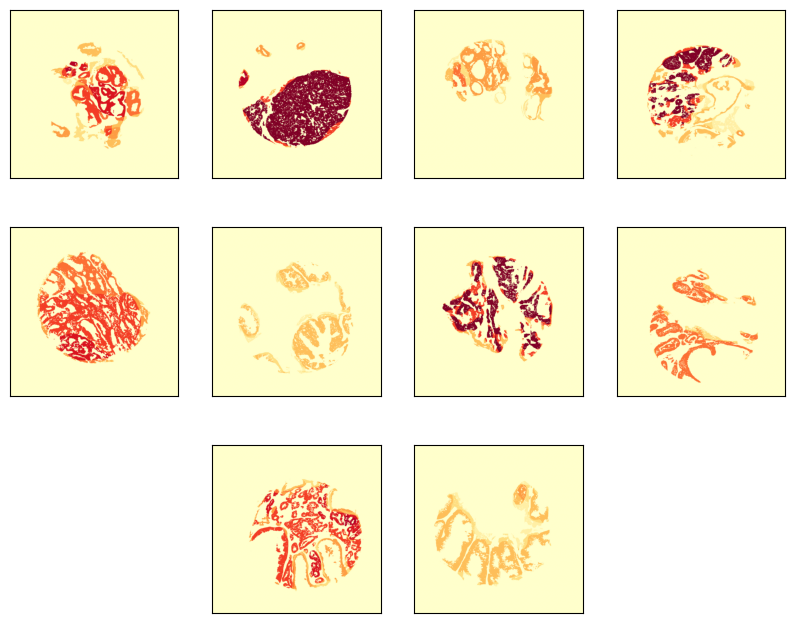

In [18]:
fig = plt.figure(figsize=(10, 8))

for i in range(len(lst)):
    j = i+1
    if i >= 8:
        j += 1
    plt.subplot(3, 4, j)
    plt.imshow((transfered_masks[i]).astype(np.uint8) + (patholog_A_masks[i]).astype(np.uint8) + (patholog_B_masks[i]).astype(np.uint8), vmin = 0, vmax = 9, cmap = 'YlOrRd')
    plt.xticks([])
    plt.yticks([])
    
plt.show()